<a href="https://colab.research.google.com/github/DavidDink/Palmers-penguins-species-classification/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group Contributions Statement

We all collaborated to import the data and write the functions that clean it. In the data visualization and feature selection section, Hannah led the creation of the scatter plot matrix, David led the creation of the box plot visualization, and Katrina led the creation of the histograms. Hannah and David led the creation of the draw_decision_boundaries function, and we all worked together to ensure that sections flowed together and proper descriptions were in place. Hannah created the SVM model, David created the Logistic Regression Model, and Katrina created the Random Forest Model. We all wrote the final comparison between models together.

# Data Import

Hi, welcome to our project! Our goal is to use a set of data on penguins to create a model that will accurately predict penguin species based on just a few penguin features. To begin our project we will import the penguins data, along with the python packages that will help us explore and model it!

In [ ]:
#importing all packages we will need later
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.colors

#importing penguins data
url = 'https://philchodrow.github.io/PIC16A/datasets/palmer_penguins.csv'
penguins = pd.read_csv(url)

Before we start lets take a look at the penguins dataframe we imported:

In [ ]:
penguins

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN


We see the dataframe has data on 344 penguins, and 16 columns of data.
These columns could potentially be used to predict the "Species" column, but in this task we will need to choose only 3 columns that can effectively predict a penguin's species.

Before we do any machine learning or data cleaning, we must split our data into a training and testing subset, to ensure we don't double dip and test our model with data we used to train it.

In [ ]:
train, test = train_test_split(penguins, test_size = 0.2)
print(np.shape(train))

(275, 17)


As we can see, we are left with a 275 randomly selected rows from the original data that we can use to train machine learning models

# Data Cleaning

Before we start any data analysis, we need to clean the dataframe to make it more readable. Because we are going to need to clean the test and train datasets separately in the same way, we are going to define a function that takes in a dataframe and cleans it.

In [ ]:

def cleanData(df):
  '''
  This function is used to clean the penguins data set. It gets applied separately
  to the training and testing set and it removes unessesary columns, faulty inputs,
  missing values, and it recodes qualitative features to have a numerical value as well.
  It takes in a pandas dataframe of penguins data.

  '''
  #drop columns and data points that we will not be using in our analysis
  df = df[df.Sex !="."]
  df = df.drop(["studyName", "Region", "Stage", "Individual ID",
                "Clutch Completion", "Date Egg","Comments", "Sample Number"], axis = 1)
  df = df.dropna()

  #recode all qualitative features to numerical values to allow for data analysis later
  recodeSex = {
    "MALE":0,
    "FEMALE":1
  }
  df["Sex"]=df["Sex"].map(recodeSex)
  recodeIsland = {
    "Dream":0,
    "Torgersen":1,
    "Biscoe":2
  }
  df["Island"]=df["Island"].map(recodeIsland)

  #shorten species name
  df["Species"] = df["Species"].str.split().str.get(0)

  #return cleaned dataframe
  return df

Let's apply the function we just wrote to the train dataset and visualize it to see what it looks like now.

In [ ]:
train = cleanData(train)
train

,Species,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
18,Adelie,1,34.4,18.4,184.0,3325.0,1,8.47827,-25.23319
6,Adelie,1,38.9,17.8,181.0,3625.0,1,9.18718,-25.21799
155,Chinstrap,0,45.4,18.7,188.0,3525.0,1,8.64701,-24.62717
147,Adelie,0,36.6,18.4,184.0,3475.0,1,8.68744,-25.83060
201,Chinstrap,0,49.8,17.3,198.0,3675.0,1,9.32169,-24.41562
...,...,...,...,...,...,...,...,...,...
251,Gentoo,2,42.8,14.2,209.0,4700.0,1,7.63452,-25.46327
70,Adelie,1,33.5,19.0,190.0,3600.0,1,7.88863,-26.63085
229,Gentoo,2,46.8,15.4,215.0,5150.0,0,8.16310,-25.38017
5,Adelie,1,39.3,20.6,190.0,3650.0,0,8.66496,-25.29805


Now our training dataset is much more manageable after we have removed all invalid datapoints and columns that do not contain useful information.

We will apply the same function to the test dataset, but will not visualize it so as to preserve an unbiased evaluation when evaluating our machine learning models later.

# Data Visualization and Feature Selection

In this project, we need to use only one qualitative feature and two quantitative features in order to make a prediction. In order to get a sense of what our data looks like and decide which features we should use, we'll need to visualize our data to better understand it.

Let's start by viewing the mean of each feature by Species.

In [ ]:
train.groupby(["Species"]).mean()

,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
Species,,,,,,,,
Adelie,0.954128,38.803670,18.361468,190.642202,3707.798165,0.495413,8.884605,-25.798970
Chinstrap,0.000000,48.773684,18.321053,195.456140,3702.192982,0.508772,9.408050,-24.568619
Gentoo,2.000000,47.515054,14.951613,217.247312,5108.064516,0.505376,8.230303,-26.196093


Since we've converted even our qualitative types into numeric values, even these averages can give us some insight as well. Here are some key takeaways

 - The penguins are definitely not spread evenly between the islands
 - Short culmen lengths are more common for Adelie penguins
 - Gento penguins seem to have shorter culmen depths, longer flippers, and larger mass

It's hard to see what's going on in the table, so lets make some box plots to compare how these penguins stack up to each other when we compare their quantitative features. The goal here is to try and figure out which two quantitative features will be the most helpful in our analysis.

We also include a heuristic that may be helpful in deciding which features can be used to distinguish the penguins apart. The total number of overlapping points counts how many data points lie in the range of another species data.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

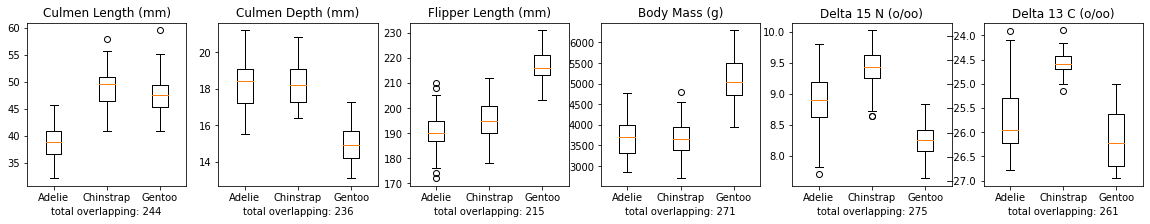

In [ ]:
# create masks to filter by species
adelie_mask = train["Species"]=="Adelie"
chinstrap_mask = train["Species"]=="Chinstrap"
gentoo_mask = train["Species"]=="Gentoo"

# gather species types
species_types = set(train['Species'])

# be able to convert species type to its corresponding mask
species_to_mask = {"Adelie":adelie_mask,"Chinstrap":chinstrap_mask,"Gentoo":gentoo_mask}

# the list of quantitative features
quant_features = [
           "Culmen Length (mm)",
          "Culmen Depth (mm)",
          "Flipper Length (mm)",
          "Body Mass (g)",
           "Delta 15 N (o/oo)",
           "Delta 13 C (o/oo)",
]

# initialize plot
fig,ax = plt.subplots(1,6,figsize = (20,3));

# create a box plot for each quantitative feature
for i in range(len(quant_features)):

  # determine the total number of overlapping data points for each quantitative feature
  totalOverlapping = 0

  # must compare each combination of species for overlapping points
  for s in species_types:
    comparison = species_types - {s}
    comparison = list(comparison)
    t0 = comparison[0]
    t1 = comparison[1]

    # for the given feature, find the minima and maxima for the two species we are comparing
    t0min = train[species_to_mask[t0]][quant_features[i]].min()
    t1min = train[species_to_mask[t1]][quant_features[i]].min()
    t0max = train[species_to_mask[t0]][quant_features[i]].max()
    t1max = train[species_to_mask[t1]][quant_features[i]].max()

    # the notable points are all the minumum and maxium.
    notable_points = []
    notable_points.append(t0min)
    notable_points.append(t0max)
    notable_points.append(t1min)
    notable_points.append(t1max)

    # The middle two values define upper and lower limits for overlapping region
    notable_points.sort()
    lower_lim = notable_points[1]
    upper_lim = notable_points[2]

    # define a mask to restrict data points to overlapping region
    lower_mask = train[quant_features[i]] >= lower_lim
    upper_mask = train[quant_features[i]] <= upper_lim

    # count how many points of each lie in the overlapping region
    count0 = len(train[species_to_mask[t0]][lower_mask][upper_mask])
    count1 = len(train[species_to_mask[t1]][lower_mask][upper_mask])

    # add this to the total overlapping count
    totalOverlapping += count0
    totalOverlapping += count1

  # create a boxplot with a plot for each species of penguin
  ax[i].boxplot([train[adelie_mask][quant_features[i]],train[chinstrap_mask][quant_features[i]],train[gentoo_mask][quant_features[i]]])
  ax[i].set_xticklabels(['Adelie','Chinstrap','Gentoo'])
  ax[i].set_title(quant_features[i])
  ax[i].set_xlabel("total overlapping: " + str(totalOverlapping))

- This visualization seems to support our data from the table above. Culmen Length seems to distinguish **Adelie** penguins very well, and Culmen Depth, Flipper Length, and Body Mass seem to distinguish **Gentoo** penguins well.

- Another metric to note is the amount of cross-species overlap between data points. Looking at this metric, it seems that Flipper Length, Delta 13 C(o/oo), and Culmen Depth would be good choices, although Flipper Length stands out in this category.

- It seems reasonable that we should choose a feature here that is good at distinguishing between at least one type of penguin. Therefore, either **Culmen Length** or Flipper Length should be one of the features in our model (or both).


Now, we'll create a matrix visualizing all the ways that the features correlate with each other. The goal here is to not use two features that are highly correlated, because this would make our model redundant and prone to overfitting.

In [ ]:
def scatterplot_matrix(cols, figsize):
    '''
    create a scatterplot matrix with a separate scatterplot for every possible pair of variables
    parameter cols is a list of strings, each of which are the name of a column
    paremeter figsize is the desired figure size of the overall scatterplot matrix
    '''
    dimensions = len(cols) #dimensions of matrix
    fig, ax = plt.subplots(dimensions, dimensions, figsize = figsize)

    #loop through each row and column
    for r in cols:
        for c in cols:
            rowNum = cols.index(r)
            colNum = cols.index(c)

            if c != r: #excludes case where variable is plotted against itself

                # get the correlation coefficient for the two variables
                corr = np.corrcoef(train[r], train[c])

                ax[rowNum,colNum].scatter(train[r],train[c],label = np.round(corr[1][0],2))
                ax[rowNum,colNum].set(xlabel=str(r),ylabel=str(c))
                ax[rowNum,colNum].legend()


    plt.tight_layout()

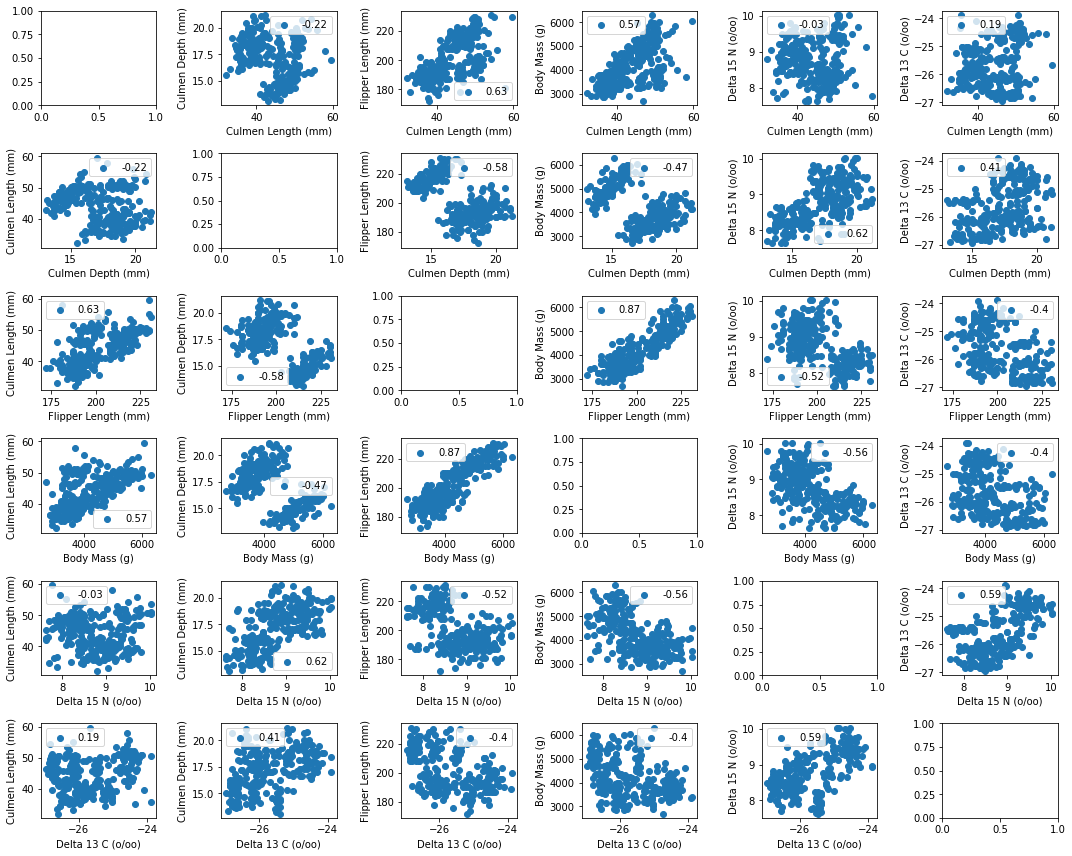

In [ ]:
scatterplot_matrix(quant_features,figsize=(15,12))

 - If we use **Culmen Length** in our model, the top row suggests that a good feature to pair with it would be Culmen Depth, Delta 13 C (o/oo), or Delta 15 N (o/oo) because these features have little correlation with Culmen Length. However, for the reasons above, **Culmen Depth** seems to be the best pair for Culmen Length.

 - If we use **Flipper Length** in our model, we should also use **Culmen Length** because Culmen Length seems to distinguish Adelie penguins very well, while Flipper Length distinguishes Gentoo penguins well.

- This reaffirms our suspicion that two features that both specialize in identifying Gentoo penguins should not be used, as we can see Body Mass and Flipper Length are highly correlated.

At this point, we have a couple options for the quantitative features we would like to use. However, we still have a choice between using Island or Sex. The tables below may help us decide.

In [ ]:
train.groupby(["Species","Island"])[["Island"]].count()

Island
Species   Island        
Adelie    0           39
          1           36
          2           34
Chinstrap 0           57
Gentoo    2           93

In [ ]:
train.groupby(["Species","Sex"])[["Sex"]].count()

Sex
Species   Sex     
Adelie    0     55
          1     54
Chinstrap 0     28
          1     29
Gentoo    0     46
          1     47

If we look at penguin species by sex, they are split fairly evenly. If we analyze them by island we can see some interesting results. **Chinstrap** and **Gento** Penguins only exist on one island each, so Island may be a great feature to use in our model. Also, the fact there are three islands and only two sexes may come in handy. However, this is just speculation, and Sex may actually be a better feature when paired with the other columns, so ultimitely we'll test both features out in our models and choose the better one.

Since we think using Island might be a great option, we will look at how the quantitative features vary based on island by creating histograms to compare each feature for each island.

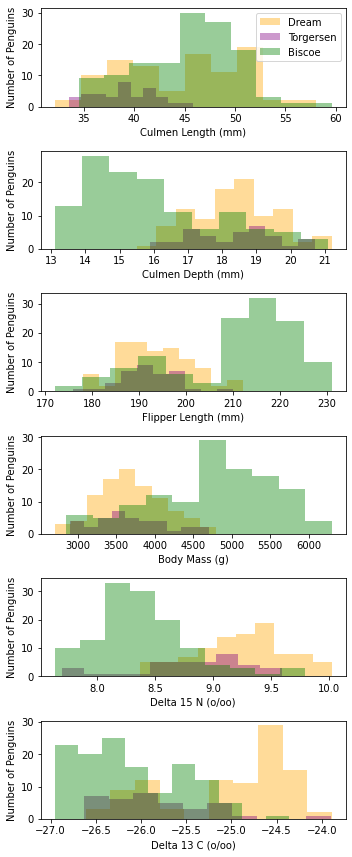

In [ ]:
#creates masks to look at the data for each island individually
x=train['Island']==0
y=train['Island']==1
z=train['Island']==2

#creates a list of the quantitative features we will use
features=["Culmen Length (mm)",
          "Culmen Depth (mm)",
          "Flipper Length (mm)",
          "Body Mass (g)",
           "Delta 15 N (o/oo)",
           "Delta 13 C (o/oo)"
]

fig, axs=plt.subplots(6, figsize=(5,12))

#for each feature plots on a new subplot
for i in range(6):
  feat=features[i]
  #set axes labels
  axs[i].set(xlabel=feat, ylabel="Number of Penguins")
  axs[i].hist(train[x][feat], alpha=.4, color="orange", label= "Dream")
  axs[i].hist(train[y][feat], alpha=.4, color="purple", label="Torgersen")
  axs[i].hist(train[z][feat], alpha=.4, color="green", label="Biscoe")

  plt.tight_layout()
  #adds legend to first subplot
  axs[0].legend()


We also don't want our quantitative features to highly correlate with our qualitative features, again because we don't want a redundant model that could be prone to overfitting.

- We can see that Delta 13 C (o/oo) and Delta 15 C(o/oo) have very different values depending on the island, so they might be highly correlated. This reaffirms that they are not great choices for our model
- Culmen Length seems to have little correlation with island, so using this feature seems to be a good choice in order to avoid overfitting.


Now we have four possible scenarios for feature combinations to use in our models. Lets visualize all of them to see how a machine learning model might draw decision boundaries to distinguish between them.

In [ ]:
def plot_penguins(quant1,quant2,qual):
  fgrid = sns.relplot(x = quant1,
                    y = quant2,
                    col = qual,
                    hue = "Species",
                    s = 100,
                    data = train)

  if qual == "Island":
    fgrid.axes[0][0].set(title  = "Dream")
    fgrid.axes[0][1].set(title  = "Torgersen")
    fgrid.axes[0][2].set(title  = "Biscoe")
  else:
    fgrid.axes[0][0].set(title  = "Male")
    fgrid.axes[0][1].set(title  = "Female")

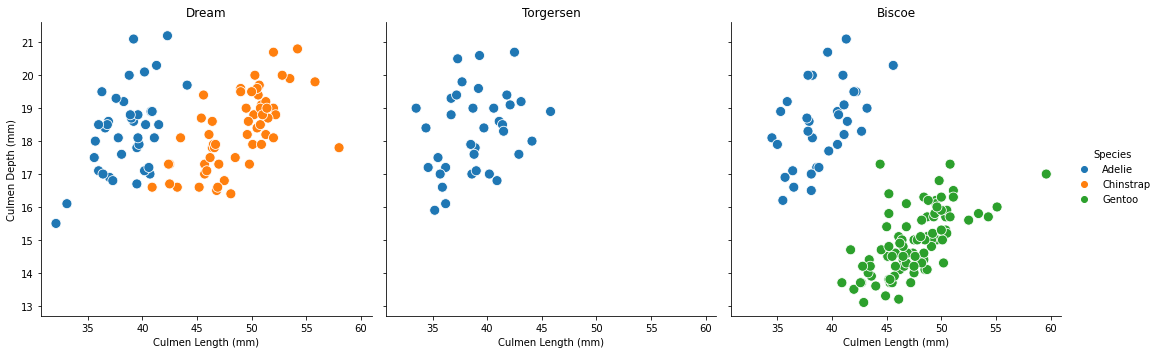

In [ ]:
plot_penguins("Culmen Length (mm)","Culmen Depth (mm)","Island")

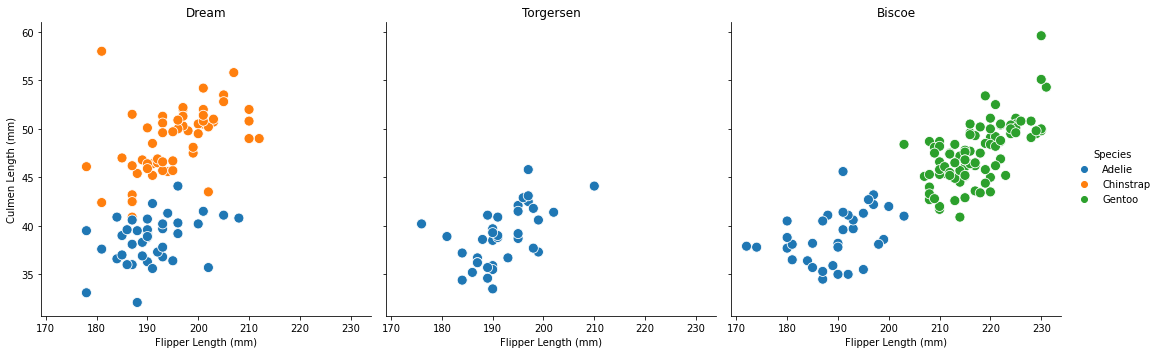

In [ ]:
plot_penguins("Flipper Length (mm)","Culmen Length (mm)","Island")

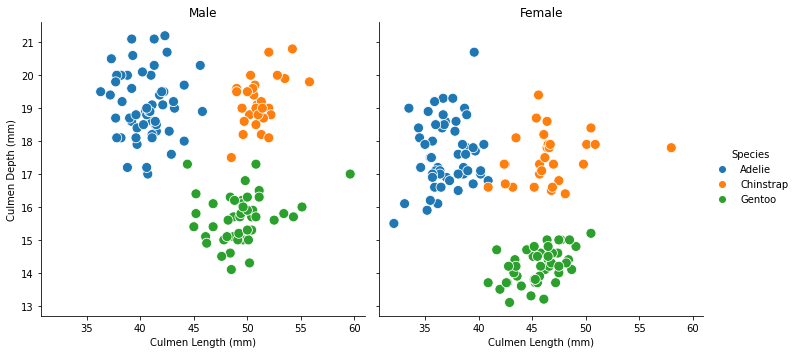

In [ ]:
plot_penguins("Culmen Length (mm)","Culmen Depth (mm)","Sex")

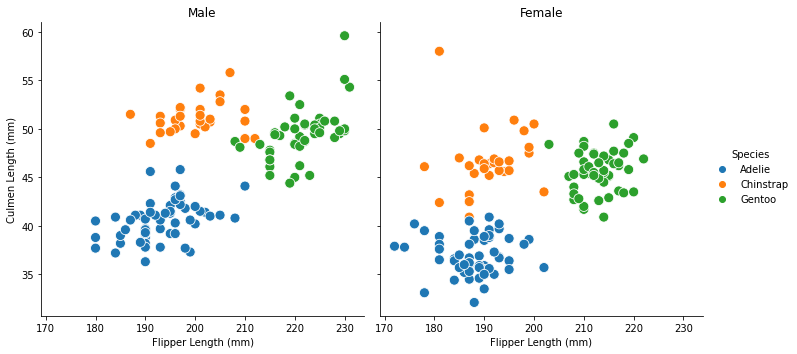

In [ ]:
plot_penguins("Flipper Length (mm)","Culmen Length (mm)","Sex")

It seems that accurate decision regions could be drawn from any of these plots, so it seems that we'd be able to build an accurate model from any one of these four column combinations.

# Machine Learning Models

Before we begin creating our models, we will first define a few functions we may need to use.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
def mistakes(y_test, X_test, y_test_pred):

  """
  A function to output a dataframe showing the actual and predicted species
  for each mistake a model made. Takes in the y_test, X_test, and predicted
  y test values.

  """
  mask=y_test!=y_test_pred
  mistakes=X_test[mask]
  mistake_labels=y_test[mask]
  mistake_preds=y_test_pred[mask]

  mistakes = pd.DataFrame({
      "Actual":mistake_labels,
      "Predicted":mistake_preds
  })
  return mistakes

The function species_to_numeric will be used later on to convert a species name to a numeric value to allow for certain data processing to be made possible.

In [ ]:
def species_to_numeric(Z):
  '''
  Takes in an array of Species and converts them to numeric values
  '''

  Z[Z=="Adelie"]=0
  Z[Z=="Chinstrap"]=1
  Z[Z=="Gentoo"]=2
  Z = Z.astype(int)
  return Z

For all three machine learning models we are going to be implementing, we are going to want to visualize the decision regions generated by the model and compare it to the actual species of each penguin datapoint. The following function draw_decision_boundaries() can be used by any of the machine learning models we are going to use to generate a visualization of its decision boundaries.

In [ ]:
def draw_decision_boundaries(data,model,cols,quantFeature):
  '''
  This function takes in cleaned train or test data and a machine learning model
  to create a figure visualizing decision boundaries.
  There are separate subplots for each value of a qualitative feature.

  parameter data is a pandas dataframe where each row will be a point plotted on the figure
  parameter model is the machine learning model used to create the decision boundaries
  parameter cols is a list of the names of columns used to create the ML model. each name should be a string
  and the quantitative features should come before the qualitative features.
  parameter quantFeature is the string "Sex" or "Island" depending on which quantitative
  feature is used to create the model.
  '''
  # use specified columns
  X = data[cols]

  # drop the qualitative feature
  X_drop = X.drop([quantFeature],axis=1)

  # convert to numpy array
  X_array = X_drop.to_numpy()

  #set variables according to what quantitative feature is used
  if quantFeature == "Island":
    quantNumeric_toName = {0:"Dream",1:"Torgersen",2:"Biscoe"}
    numValues = 3
  elif quantFeature == "Sex":
    quantNumeric_toName = {0:"MALE", 1:"FEMALE"}
    numValues = 2

  #create figure with subplots corresponding to each value of the qualitative variable
  fig,ax = plt.subplots(1,numValues,figsize = (20,5))

  #loop through number of values of quantitative feature to create each subplot
  for value in range(numValues):
    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max]x[y_min, y_max]
    flip_min, flip_max = X_array[:, 0].min() - 0.5, X_array[:, 0].max() + 0.5
    cul_min, cul_max = X_array[:, 1].min() - 0.5, X_array[:, 1].max() + 0.5


    h = 0.05  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(flip_min, flip_max, h), np.arange(cul_min, cul_max, h))
    val = value*np.ones(len(xx.ravel()))

    # predict species using our model
    Z = model.predict(np.c_[xx.ravel(), yy.ravel(),val])

    # relable the species for colormap purposes
    Z = species_to_numeric(Z)

    # Put the result into a color plot
    color_map = matplotlib.colors.ListedColormap(['thistle','lightcoral','mediumaquamarine'])
    Z = Z.reshape(xx.shape)
    ax[value].pcolormesh(xx, yy, Z,cmap=color_map)

    qualFeat1 = cols[0]
    qualFeat2 = cols[1]

    #set colors for each species, should be the same as the color map used for the meshgrid
    species_colors = {"Adelie":'thistle',"Chinstrap":'lightcoral',"Gentoo":'mediumaquamarine'}

    #group data according to species
    groups = data[data[quantFeature] == value].groupby("Species")

    #plot each species on a plot with color defined by the dictionary species_colors
    for name, group, in groups:
      ax[value].plot(group[qualFeat1], group[qualFeat2], marker='o',
                     markeredgecolor = 'k',linestyle='', color = species_colors[name], markersize=4, label=name)

    #set labels and legend
    ax[value].set(xlabel = cols[0],ylabel = cols[1],title = quantNumeric_toName[value])
    ax[value].legend()

  #make title for entire figure
  fig.suptitle("Decision Boundaries by " + quantFeature)

## Multinomial logistic regression model

Multinomial Logistic Regression is a version of Logistic Regression that is suited to classify between multiple categories. A sigmoid function is fit to the data, which is used to estimate a probablity that an object falls into a specific category. The classification is made by predicting that the object falls into the category under which it has the highest predicted probablilty.

Since we are using only three features, Logistic Regression is a good choice to avoid overfitting. Since it draws linear decision boundaries, often this may oversimplify things, but in our case it looks like an accurate prediction will be able to be made.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# We'll save our own version of the training data to ensure that we don't tamper with it for future modeling
logisticTrain = train.copy()

Let's see which of the four sets of columns allows us to fit the best model

In [ ]:
column_combos = [
                 ["Culmen Length (mm)","Culmen Depth (mm)","Island"],
                 ["Culmen Length (mm)","Culmen Depth (mm)","Sex"],
                 ["Flipper Length (mm)","Culmen Length (mm)","Island"],
                 ["Flipper Length (mm)","Culmen Length (mm)","Sex"],
]

Now we'll create a logistic regression model. We'll use the default value of c for now


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
best_combo = []
best_score = -np.inf

# try out each column combination
for cols in column_combos:

  # separate the features and the target using the given columns
  X_train = logisticTrain[cols]
  y_train = logisticTrain['Species']

  # create a model to fit the data and score it
  model = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=1000)
  model.fit(X_train,y_train)
  score = model.score(X_train,y_train)
  print(cols,score)


['Culmen Length (mm)', 'Culmen Depth (mm)', 'Island'] 0.9961389961389961
['Culmen Length (mm)', 'Culmen Depth (mm)', 'Sex'] 0.9884169884169884
['Flipper Length (mm)', 'Culmen Length (mm)', 'Island'] 0.9806949806949807
['Flipper Length (mm)', 'Culmen Length (mm)', 'Sex'] 0.9652509652509652


It seems our model performed pretty well, at least on our training data set. As predicted, all column combos were able to fit the data well, but let's use the first combination because it gave the best fit: **Culmen Length (mm), Culmen Depth (mm), Island**

For multinomial logistic regression, we also can choose a parameter c which may or may not give different outputs in our model. Let's use cross validation to see if we can find a better parameter c to use, and also test the model accuracy on small subsets of unseen data

In [ ]:
cols = column_combos[0]

In [ ]:
# pool of test c values to choose from
C_pool=np.linspace(0.01,.5,10)

best_score = -np.inf

# create a new model for each c value
for c in C_pool:

    # separate the features and the target using the given columns
    X_train = logisticTrain[cols]
    y_train = logisticTrain['Species']

    # create a model to fit the data with a variable C parameter
    LR = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=1000,C=c)
    model.fit(X_train,y_train)

    # get the cross validation score
    score = cross_val_score(LR,X_train,y_train,cv=5).mean()

    # if score is better than best, update it
    if score>best_score:
        best_score=score
        best_c=c

    print('c= '+str(np.round(c,5)),"Cross Validation Score= ",score)

print("best c: " + str(np.round(best_c,3)))

c= 0.01 Cross Validation Score=  0.9611613876319758
c= 0.06444 Cross Validation Score=  0.9727752639517346
c= 0.11889 Cross Validation Score=  0.9766968325791856
c= 0.17333 Cross Validation Score=  0.9844645550527904
c= 0.22778 Cross Validation Score=  0.9844645550527904
c= 0.28222 Cross Validation Score=  0.9883107088989442
c= 0.33667 Cross Validation Score=  0.9883107088989442
c= 0.39111 Cross Validation Score=  0.9883107088989442
c= 0.44556 Cross Validation Score=  0.9883107088989442
c= 0.5 Cross Validation Score=  0.9922322775263952
best c: 0.5


Looks like our model will predict with fairly good accuracy! Let's put it to the test with our testing data set with the parameter of C that we chose

In [ ]:
logisticTest = cleanData(test)
X_test = logisticTest[cols]
y_test = logisticTest['Species']

In [ ]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs',max_iter=1000,C=best_c)
model.fit(X_train,y_train)

LogisticRegression(C=0.5, max_iter=1000, multi_class='multinomial')

In [ ]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.9922779922779923
1.0


We can see we predicted with high accuracy! Let's see where our model went wrong and predicted the testing data incorrectly

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_test_pred = model.predict(X_test)
c=confusion_matrix(y_test,y_test_pred)
c

array([[30,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 25]])

In [ ]:
y_test_pred=model.predict(X_test)
mistakes(y_test, X_test, y_test_pred)

,Actual,Predicted


Now let's plot the decision regions to view how our model worked so we can identify the few errors

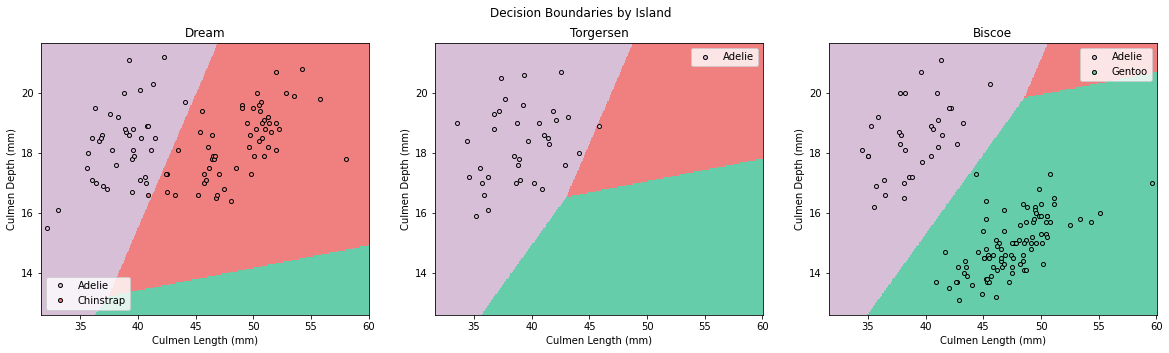

In [ ]:
# Training Data
draw_decision_boundaries(logisticTrain,model,cols,"Island")

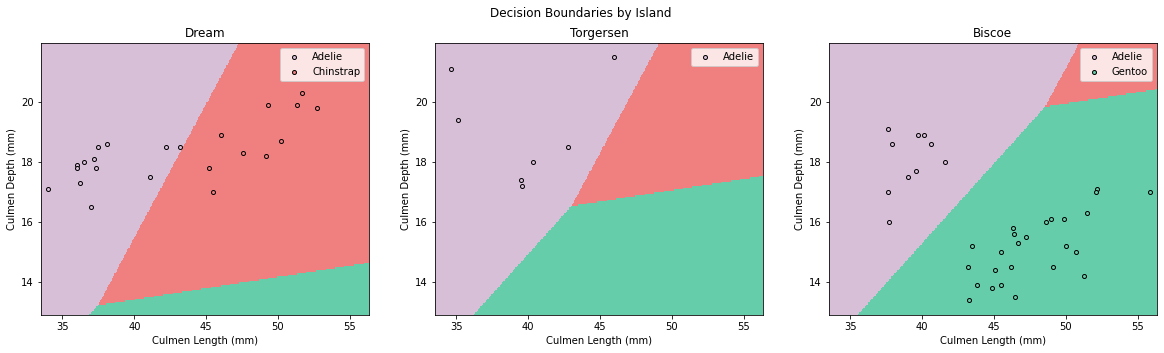

In [ ]:
# Testing Data
draw_decision_boundaries(logisticTest,model,cols,"Island")

This model did an excellent job fitting the data and classifying our dataset. With how well it performed, overfitting is always a valid concern. However, given the linear decision boundaries, we can clearly see that the model isn't overfitting. Admittedly, our data set is not large though, and its valid to wonder how well this model would do on a larger data set. Another possible limmitation is that if this model were to be adapted to classify between more types of penguins, or if more unique data points were collected, the linear decision boundaries might not suffice. We'll see how a couple different models perform differently in these ways.

# Random Forest Model


Now we're going to try a different model, the Random Forest Model!

A random forest model fits many different decision trees on various subsets of the training data. The Random Forest Model selects random samples from the training data and creates a decision tree for each sample. It uses these decision trees to predict an outcome. The advantages of this model are that it doesn't overfit because it uses many decision trees to make a final prediction, and it is usually pretty accurate. This model's disadvantage is that it is slow because it must construct many decision trees.

In [ ]:
#import package to creat model and copy training data
from sklearn.ensemble import RandomForestClassifier
forestTrain= train.copy()


In [ ]:
forestTest =cleanData(test)
#filter test data to include chosen features
Xf_test = forestTest[['Flipper Length (mm)','Culmen Length (mm)','Sex']]
yf_test = forestTest['Species']

In [ ]:
#filter train data to include chosen features
Xf_train = forestTrain[['Flipper Length (mm)','Culmen Length (mm)','Sex']]
yf_train = forestTrain['Species']

In [ ]:
#cross validation to find the best depth to be used for trees in the random forest
from sklearn.model_selection import cross_val_score
best_score=-np.inf
N=10 #largest max depth
scores=np.zeros(N)

for i in range(1,N+1):
    #test the model for each depth in range 1 to 10
    m=RandomForestClassifier(n_estimators = 100, max_depth=i)
    scores[i-1]=cross_val_score(m,Xf_train,yf_train).mean()
    if scores[i-1]>best_score:
        best_depth=i
        best_score=scores[i-1]

best_depth

6

In [ ]:
#creates random forest model with best depth
m= RandomForestClassifier(n_estimators = 100, max_depth=best_depth)
m.fit(Xf_train, yf_train)

RandomForestClassifier(max_depth=6)

In [ ]:
m.score(Xf_train,yf_train)

1.0

In [ ]:
m.score(Xf_test,yf_test)

0.9846153846153847

It seems our model does not perform quite as well on the testing data, as it does the training, but overall it does pretty well!

In [ ]:
#creates confusion matrix for model
from sklearn.metrics import confusion_matrix
test_pred=m.predict(Xf_test)
confusion_matrix(yf_test, test_pred)

array([[29,  1,  0],
       [ 0, 10,  0],
       [ 0,  0, 25]])

In [ ]:
#creates dataframe of mistakes the model made
mistakes(yf_test,Xf_test,test_pred)

,Actual,Predicted
37,Adelie,Chinstrap


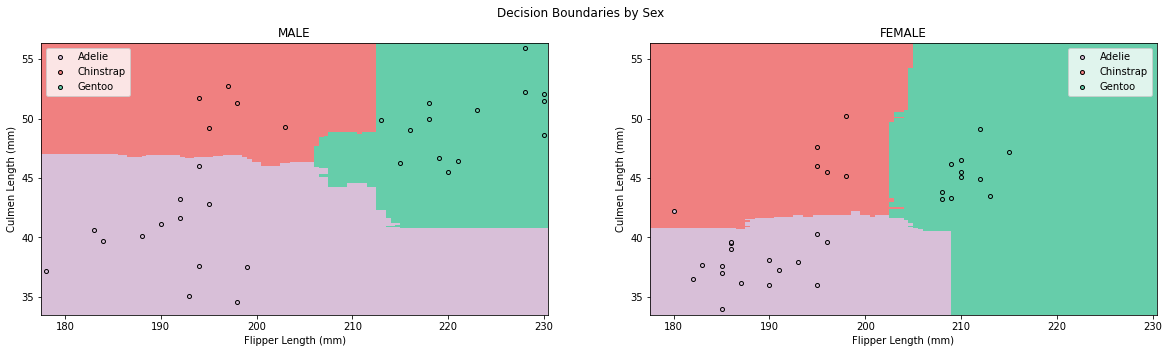

In [ ]:
#plots decision regions
cols=["Flipper Length (mm)","Culmen Length (mm)","Sex"]
draw_decision_boundaries(forestTest,m,cols,"Sex")

# Support-Vector Machine

Now we're going to try out Support-Vector Machine (SVM) as a model. Support-Vector Machine is a supervised learning model that can be used to analyze data for classification. It does so by reducing a multiclass problem into multiple binary classification problems.

First, you want to import the required package from the scikit-learn library.

In [ ]:
from sklearn import svm, datasets

Earlier in this project, we identified different 4 combinations of features that we believed might make good models. We're going to put these combinations into a list that we can use later to determine which one gives us the best cross-validation score.

In [ ]:
features = [
            ['Culmen Depth (mm)','Culmen Length (mm)', 'Island'],
            ['Flipper Length (mm)','Culmen Length (mm)', 'Island'],
            ['Culmen Depth (mm)','Culmen Length (mm)', 'Sex'],
            ['Flipper Length (mm)','Culmen Length (mm)', 'Sex']
]

SVM is capable of performing non-linear classification in addition to linear classifcation, using something called the kernel trick, which maps inputs into high-dimensional feature spaces. We will explore 4 different kernels in this project: linear, polynomial, gaussian, and sigmoid.

For each of the combinations of features, we will build models for each of these 4 kernels and evaluate their cross-validation scores to determine which model is best suited for our purposes.

In [ ]:
y_train = train[['Species']]

for feature in features:
  x_train = train[feature]
  linear = svm.SVC(kernel = 'linear', C = 1, decision_function_shape = "ovo").fit(x_train, y_train)
  rbf = svm.SVC(kernel = 'rbf', gamma = 1, C = 1, decision_function_shape = "ovo").fit(x_train, y_train)
  poly = svm.SVC(kernel = 'poly', degree = 3, C = 1, decision_function_shape = "ovo").fit(x_train, y_train)
  sig = svm.SVC(kernel = 'sigmoid', C = 1, decision_function_shape = "ovo").fit(x_train, y_train)

  crossval_lin = cross_val_score(linear,x_train,y_train,cv=5).mean()
  crossval_poly = cross_val_score(poly,x_train,y_train,cv=5).mean()
  crossval_rbf = cross_val_score(rbf,x_train,y_train,cv=5).mean()
  crossval_sig = cross_val_score(sig,x_train,y_train,cv=5).mean()

  print('Features used:', feature)
  print('linear:', crossval_lin)
  print('polynomial:', crossval_poly)
  print('gaussian:', crossval_rbf)
  print('sigmoid:', crossval_sig)
  print('\n')


Features used: ['Culmen Depth (mm)', 'Culmen Length (mm)', 'Island']
linear: 0.9922322775263952
polynomial: 0.9650075414781298
gaussian: 0.9534690799396683
sigmoid: 0.41304675716440425


Features used: ['Flipper Length (mm)', 'Culmen Length (mm)', 'Island']
linear: 0.9845399698340875
polynomial: 0.8918552036199096
gaussian: 0.8533182503770739
sigmoid: 0.42081447963800905


Features used: ['Culmen Depth (mm)', 'Culmen Length (mm)', 'Sex']
linear: 0.9922322775263952
polynomial: 0.9495475113122172
gaussian: 0.9573906485671191
sigmoid: 0.41304675716440425


Features used: ['Flipper Length (mm)', 'Culmen Length (mm)', 'Sex']
linear: 0.9536199095022624
polynomial: 0.8918552036199096
gaussian: 0.8611613876319758
sigmoid: 0.42081447963800905




From this, you can see that when the features 'Culmen Depth (mm)', 'Culmen Length (mm)', and 'Sex' are used with a linear kernel, we get the highest cross-validation score. Therefore, we will go ahead and use these parameters to train our model.

In [ ]:
best_features = ['Culmen Depth (mm)', 'Culmen Length (mm)', 'Sex']
x_train = train[best_features]
y_train = train[['Species']]
model = svm.SVC(kernel = 'linear', C = 1, decision_function_shape = "ovo").fit(x_train, y_train)

Now that we've trained our model, we can apply it to our test data and determine its accuracy.

In [ ]:
SVMTest = cleanData(test)

In [ ]:
x_test = SVMTest[best_features]
y_test = SVMTest['Species']
test_score = model.score(x_test, y_test)
print('accuracy:',test_score)

accuracy: 1.0


We can use the function mistakes() we defined previously, we can see which datapoints were incorrectly categorized according to our model.

In [ ]:
test_pred = model.predict(x_test)
mistakes(y_test,x_test,test_pred)

,Actual,Predicted


We can also visualize the decision boundaries created by our model and see how the datapoints from the train dataset correlate to the decision regions.



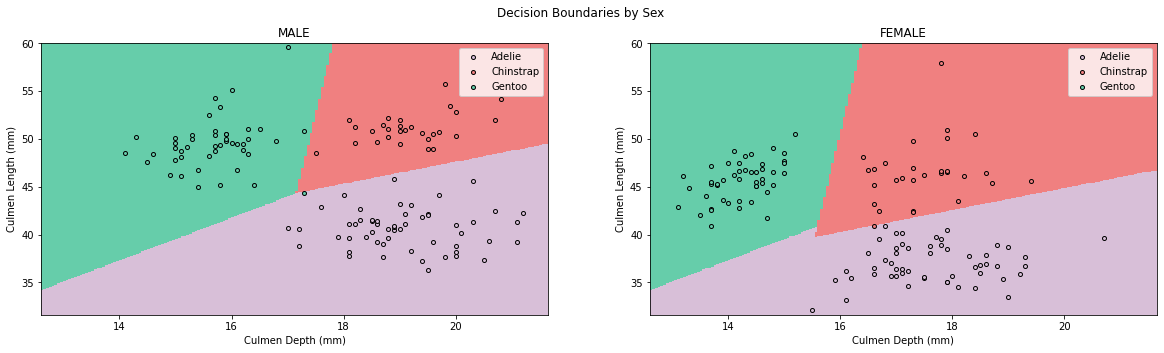

In [ ]:
draw_decision_boundaries(train, model, best_features, "Sex")

The same can be done for the test data.

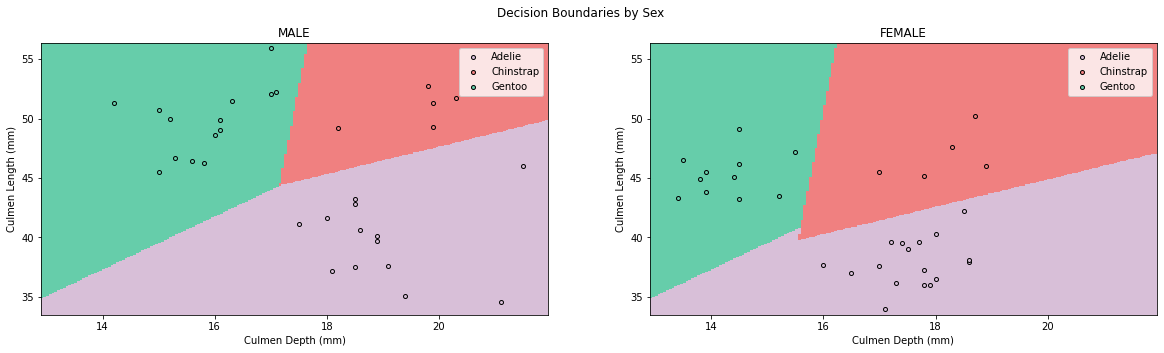

In [ ]:
draw_decision_boundaries(SVMTest, model,best_features, "Sex")

As you can see, Support-Vector Machine is able to create very good models for classification. In general, SVM is effective in high-dimensional spaces and is also fairly versatile. Because it can handle multiple different kernels, it is fairly flexible and is able to be applied to many different situations. However, in order for it to be effective, the correct parameters and kernel need to be chosen. This is why it was important to conduct cross-validation to show which kernel and parameters made the best model.

# Model Comparision

All three models performed very well, so choosing which one performed the best is left up to an element of subjectivity. Since we chose features to use in our model that were highly distingusihing of the data points, every model we used was able to predict with high accuracy. Looking at the decision regions, it seems like the SVM and the Logistic Regression Model chose very similar decision regions, so the better model out of those two is the one that would run in a shorter amount of time. Since the SVM takes a while to train, the Logistic Regression Model may be a better choice for this reason. The random forest model drew decision regions that were distinct from both the other two models. These regions visually were less linear, so the model may perform and scale well to other data sets.